In [ ]:
import pandas as pd  # data handling
import sys  # access to system internals
import os  # filesystem utilities
sys.path.append(os.path.abspath(".."))  # allow importing project modules from parent
import scripts.plot_utils as plot_utils  # helper to save plots automatically
import seaborn as sns  # plotting helper
import matplotlib.pyplot as plt  # matplotlib interface

In [2]:
mat = pd.read_csv("../data/raw/student-mat.csv" , encoding="utf-8", sep=";")  # load math dataset
por = pd.read_csv("../data/raw/student-por.csv" , encoding="utf-8", sep=";")  # load Portuguese dataset

In [3]:
mat.head()  # preview first rows of math dataset

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
mat.info()  # schema/nonnull counts for math dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
mat.isnull().sum()  # missing values per column (math)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
numeric_df = mat.select_dtypes(include=["int64", "float64"])  # numeric subset (math)

Q1 = numeric_df.quantile(0.25)  # first quartile
Q3 = numeric_df.quantile(0.75)  # third quartile
IQR = Q3 - Q1  # interquartile range

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))  # Tukey rule for outliers
outliers.sum().sort_values(ascending=False)  # count outliers per feature


failures      83
studytime     27
famrel        26
freetime      19
Dalc          18
absences      15
G2            13
traveltime     8
Fedu           2
age            1
Medu           0
goout          0
Walc           0
health         0
G1             0
G3             0
dtype: int64

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


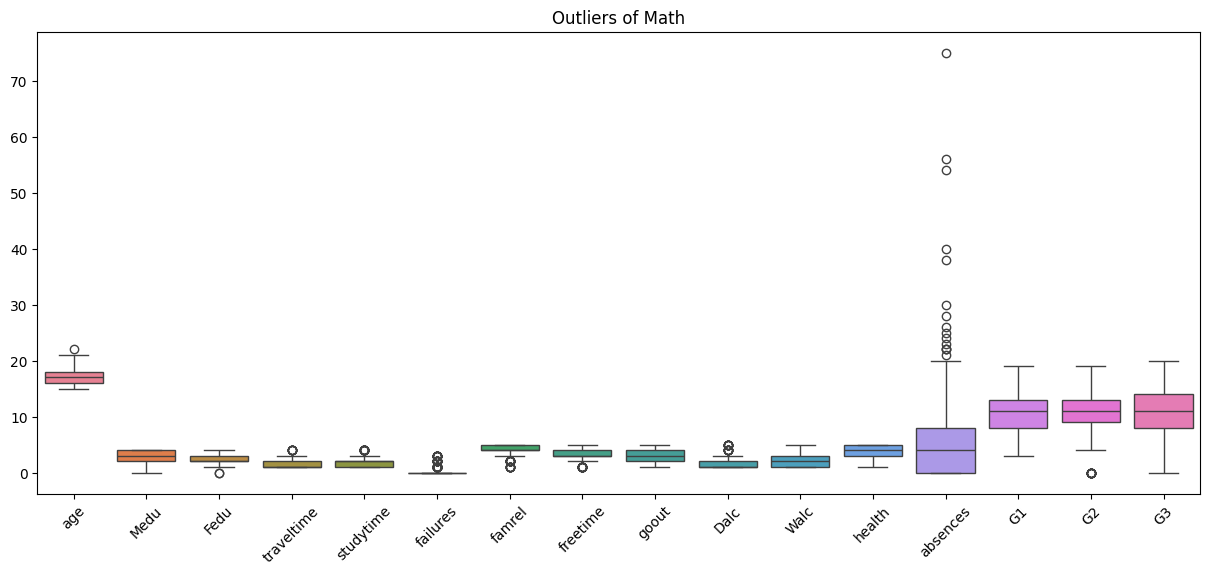

In [6]:
plt.figure(figsize=(15, 6))  # new figure for boxplot
sns.boxplot(data=numeric_df)  # boxplots of numeric math features
plt.xticks(rotation=45)  # rotate x labels
plt.title("Outliers of Math")  # title
plot_utils.save_all_figs("Outliers of Math" , "Raw")  # save plot image
plt.show()  # display plot

In [7]:
por.head()  # preview first rows of Portuguese dataset

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [8]:
por.info()  # schema/nonnull counts for Portuguese dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
por.isnull().sum()  # missing values per column (Portuguese)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [10]:
numeric_df2 = por.select_dtypes(include=["int64", "float64"])  # numeric subset (Portuguese)

Q1 = numeric_df2.quantile(0.25)  # first quartile
Q3 = numeric_df2.quantile(0.75)  # third quartile
IQR = Q3 - Q1  # interquartile range

outliers = (numeric_df2 < (Q1 - 1.5 * IQR)) | (numeric_df2 > (Q3 + 1.5 * IQR))  # Tukey rule for outliers
outliers.sum().sort_values(ascending=False)  # count outliers per feature

failures      100
famrel         51
freetime       45
studytime      35
Dalc           34
G2             25
absences       21
traveltime     16
G1             16
G3             16
age             1
Medu            0
Fedu            0
goout           0
Walc            0
health          0
dtype: int64

All figures saved in /home/norbert/Projects/Student Performance/reports/Datasets


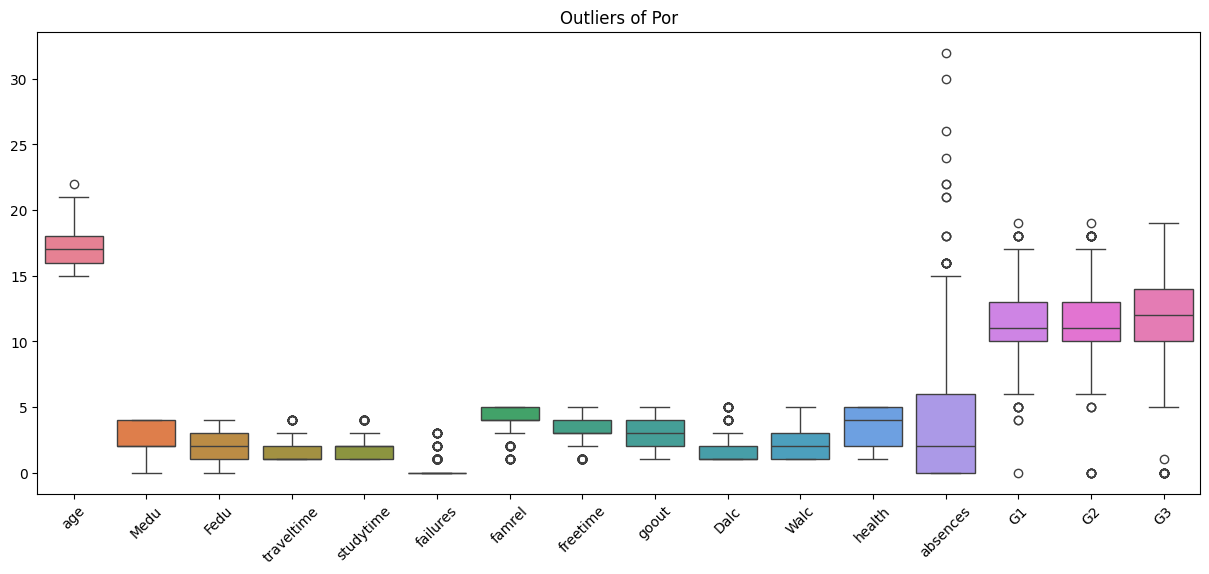

In [11]:
plt.figure(figsize=(15, 6))  # new figure for boxplot
sns.boxplot(data=numeric_df2)  # boxplots of numeric Portuguese features
plt.xticks(rotation=45)  # rotate x labels
plt.title("Outliers of Por")  # title
plot_utils.save_all_figs("Outliers of Por" , "Raw")  # save plot image
plt.show()  # display plot